# AfterMath — EDA

Explore class distribution and sample before/after pairs across the four hurricane events.

In [1]:
import sys
sys.path.insert(0, '..')  # so `utils` (repo root) is importable when cwd is notebooks/

import glob
import yaml
import matplotlib.pyplot as plt
from utils.xbd_labels import parse_label_file, DAMAGE_CLASSES

config = yaml.safe_load(open('../config.yaml'))
storms = config['data']['storms']
raw_dir = '../' + config['data']['raw_dir']

## Damage class counts per storm

In [2]:
counts_per_storm = {}
for storm in storms:
    label_files = glob.glob(f'{raw_dir}/{storm}/labels/*_post_disaster.json')
    counts = {cls: 0 for cls in DAMAGE_CLASSES}
    for label_file in label_files:
        for label in parse_label_file(label_file):
            counts[label.damage_class] += 1
    counts_per_storm[storm] = counts
counts_per_storm

{'hurricane-harvey': {'no-damage': 11423,
  'minor-damage': 2663,
  'major-damage': 8238,
  'destroyed': 401},
 'hurricane-florence': {'no-damage': 4689,
  'minor-damage': 132,
  'major-damage': 1245,
  'destroyed': 54},
 'hurricane-matthew': {'no-damage': 2515,
  'minor-damage': 6548,
  'major-damage': 1945,
  'destroyed': 2147},
 'hurricane-michael': {'no-damage': 14588,
  'minor-damage': 5207,
  'major-damage': 1902,
  'destroyed': 757}}

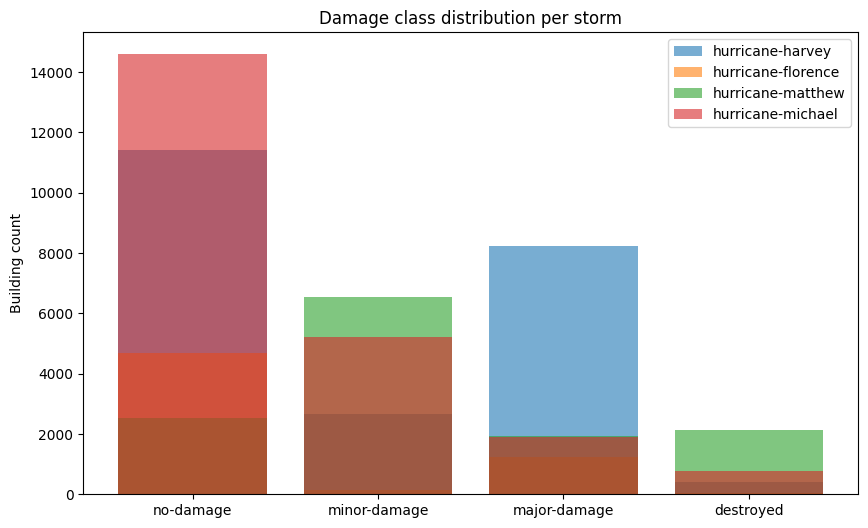

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for storm, counts in counts_per_storm.items():
    ax.bar(DAMAGE_CLASSES, list(counts.values()), alpha=0.6, label=storm)
ax.set_ylabel('Building count')
ax.set_title('Damage class distribution per storm')
ax.legend()
plt.savefig('../docs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Sample before/after image pairs

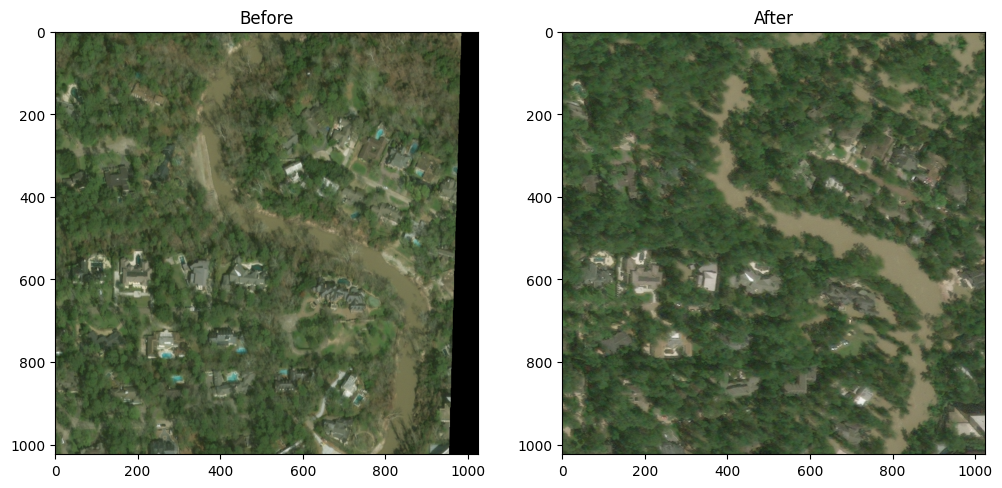

In [4]:
import random
from PIL import Image

sample_storm = storms[0]
post_files = glob.glob(f'{raw_dir}/{sample_storm}/images/*_post_disaster.png')
sample_post = random.choice(post_files)
sample_pre = sample_post.replace('_post_disaster', '_pre_disaster')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(Image.open(sample_pre))
axes[0].set_title('Before')
axes[1].imshow(Image.open(sample_post))
axes[1].set_title('After')
plt.show()